# Task 2: Empirical Diagnostic of Custom Weight Initializations and Gradient Vanishing

### Objective
Analyze training instability in a deep neural network by observing activation distributions and gradient magnitudes under different weight initialization methods.


In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Keep the experiment repeatable.
torch.manual_seed(42)
np.random.seed(42)

# We are doing all gradient calculations ourselves.
# No tensor in this experiment needs Autograd.
torch.set_grad_enabled(False)

print("PyTorch version:", torch.__version__)
print("Autograd enabled:", torch.is_grad_enabled())

PyTorch version: 2.11.0+cpu
Autograd enabled: False


## 1. Experiment Settings

In [23]:
# Input and network sizes
input_size = 64
hidden_size = 64
output_size = 10

# Exactly 20 hidden layers
hidden_layers = 20

# Training settings
batch_size = 128
epochs = 25
learning_rate = 0.001

# A small random dataset is enough for the diagnostic experiment.
X = torch.randn(batch_size, input_size)
y = torch.randint(0, output_size, (batch_size,))

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Number of hidden layers:", hidden_layers)

Input shape: torch.Size([128, 64])
Target shape: torch.Size([128])
Number of hidden layers: 20


## 2. Custom Xavier and Kaiming Initialization

The functions below are written manually instead of calling PyTorch's built-in initialization functions.


In [24]:
def custom_xavier(tensor, fan_in, fan_out):
    # Glorot/Xavier initialization.
    std = np.sqrt(2.0 / (fan_in + fan_out))
    tensor.normal_(mean=0.0, std=std)
    tensor.requires_grad = False


def custom_kaiming(tensor, fan_in):
    # He/Kaiming initialization is designed for ReLU layers.
    std = np.sqrt(2.0 / fan_in)
    tensor.normal_(mean=0.0, std=std)
    tensor.requires_grad = False


def large_random(tensor):
    # This is intentionally much larger than Xavier/He.
    # It gives us a simple unstable baseline.
    tensor.normal_(mean=0.0, std=1.0)
    tensor.requires_grad = False

## 3. Build the 20-Layer MLP

In [25]:
def build_network(initialization):
    weights = []
    biases = []

    # The first layer receives the input features.
    fan_in = input_size

    # Create 20 hidden layers.
    for _ in range(hidden_layers):
        fan_out = hidden_size

        W = torch.empty(fan_in, fan_out)
        b = torch.zeros(fan_out)

        if initialization == "xavier":
            custom_xavier(W, fan_in, fan_out)
        elif initialization == "kaiming":
            custom_kaiming(W, fan_in)
        elif initialization == "large":
            large_random(W)

        # Biases do not need gradients because we update them manually.
        b.requires_grad = False

        weights.append(W)
        biases.append(b)

        fan_in = fan_out

    # Final classification layer.
    W = torch.empty(hidden_size, output_size)
    b = torch.zeros(output_size)

    if initialization == "xavier":
        custom_xavier(W, hidden_size, output_size)
    elif initialization == "kaiming":
        custom_kaiming(W, hidden_size)
    elif initialization == "large":
        large_random(W)

    b.requires_grad = False

    weights.append(W)
    biases.append(b)

    return weights, biases


# Check the architecture.
weights, biases = build_network("xavier")

print("Number of weight matrices:", len(weights))
print("First weight shape:", weights[0].shape)
print("Last weight shape:", weights[-1].shape)
print("All weights require gradients:", any(w.requires_grad for w in weights))

Number of weight matrices: 21
First weight shape: torch.Size([64, 64])
Last weight shape: torch.Size([64, 10])
All weights require gradients: False


## 4. Manual Forward Pass

No `nn.Linear`, `loss.backward()`, optimizer, or Autograd is used.

The hidden layers use ReLU and the last layer produces logits.

In [26]:
def forward_pass(X, weights, biases):
    activations = []
    pre_activations = []

    A = X

    # Hidden layers
    for layer in range(hidden_layers):
        Z = A @ weights[layer] + biases[layer]
        A = torch.relu(Z)

        pre_activations.append(Z)
        activations.append(A)

    # Output layer
    logits = A @ weights[-1] + biases[-1]

    return logits, activations, pre_activations

## 5. Cross-Entropy Loss

We calculate softmax probabilities and cross-entropy manually.

In [27]:
def cross_entropy_loss(logits, targets):
    # Softmax converts logits into class probabilities.
    shifted = logits - logits.max(dim=1, keepdim=True).values
    exp_values = torch.exp(shifted)
    probabilities = exp_values / exp_values.sum(dim=1, keepdim=True)

    # Pick the probability assigned to the correct class.
    correct_probabilities = probabilities[
        torch.arange(targets.shape[0]), targets
    ]

    # Small epsilon prevents log(0).
    loss = -torch.log(correct_probabilities + 1e-8).mean()

    return loss, probabilities

## 6. Manual Backpropagation

In [28]:
def manual_backward(X, targets, weights, activations, pre_activations, probabilities):
    gradients = [None] * len(weights)

    # One-hot target matrix
    one_hot = torch.zeros_like(probabilities)
    one_hot[torch.arange(targets.shape[0]), targets] = 1.0

    # Gradient of softmax + cross entropy.
    dZ = (probabilities - one_hot) / X.shape[0]

    # Output layer gradient.
    previous_activation = activations[-1]
    gradients[-1] = previous_activation.T @ dZ

    # Send gradient into the last hidden layer.
    dA = dZ @ weights[-1].T

    # Move backwards through all 20 hidden layers.
    for layer in range(hidden_layers - 1, -1, -1):

        # ReLU derivative: 1 where Z > 0, otherwise 0.
        d_relu = (pre_activations[layer] > 0).float()

        dZ = dA * d_relu

        if layer == 0:
            previous_activation = X
        else:
            previous_activation = activations[layer - 1]

        gradients[layer] = previous_activation.T @ dZ

        # Pass the gradient to the previous layer.
        dA = dZ @ weights[layer].T

    return gradients

## 7. Statistics Tracking Harness



In [29]:
def create_history():
    return {
        "activation_mean": [],
        "activation_variance": [],
        "gradient_mean": [],
        "gradient_norm": [],
        "weight_mean": [],
        "weight_variance": [],
        "loss": []
    }


def record_statistics(history, activations, gradients, weights, loss):
    # Store one value per layer for this epoch.
    history["activation_mean"].append([
        a.mean().item() for a in activations
    ])

    history["activation_variance"].append([
        a.var().item() for a in activations
    ])

    history["gradient_mean"].append([
        g.abs().mean().item() for g in gradients
    ])

    history["gradient_norm"].append([
        g.norm().item() for g in gradients
    ])

    history["weight_mean"].append([
        w.mean().item() for w in weights
    ])

    history["weight_variance"].append([
        w.var().item() for w in weights
    ])

    history["loss"].append(loss.item())

## 8. Run the Three Initialization Experiments

The weights are updated manually after every epoch, so the recorded gradients are actual training gradients rather than gradients produced by PyTorch Autograd.

In [30]:
initializations = ["large", "xavier", "kaiming"]
results = {}

for initialization in initializations:

    print("\n" + "=" * 60)
    print("Running:", initialization.upper())
    print("=" * 60)

    weights, biases = build_network(initialization)
    history = create_history()

    for epoch in range(epochs):


        logits, activations, pre_activations = forward_pass(
            X, weights, biases
        )


        loss, probabilities = cross_entropy_loss(
            logits, y
        )

        gradients = manual_backward(
            X,
            y,
            weights,
            activations,
            pre_activations,
            probabilities
        )
        record_statistics(
            history,
            activations,
            gradients,
            weights,
            loss
        )
        # Manual weight update
        for i in range(len(weights)):
            weights[i] -= learning_rate * gradients[i]

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch + 1:2d} | "
                f"Loss: {loss.item():.4f}"
            )

    results[initialization] = history


Running: LARGE
Epoch  5 | Loss: nan
Epoch 10 | Loss: nan
Epoch 15 | Loss: nan
Epoch 20 | Loss: nan
Epoch 25 | Loss: nan

Running: XAVIER
Epoch  5 | Loss: 2.3025
Epoch 10 | Loss: 2.3025
Epoch 15 | Loss: 2.3025
Epoch 20 | Loss: 2.3025
Epoch 25 | Loss: 2.3025

Running: KAIMING
Epoch  5 | Loss: 2.4202
Epoch 10 | Loss: 2.3957
Epoch 15 | Loss: 2.3778
Epoch 20 | Loss: 2.3630
Epoch 25 | Loss: 2.3511


## 9. Plot Activation Mean Across Epochs

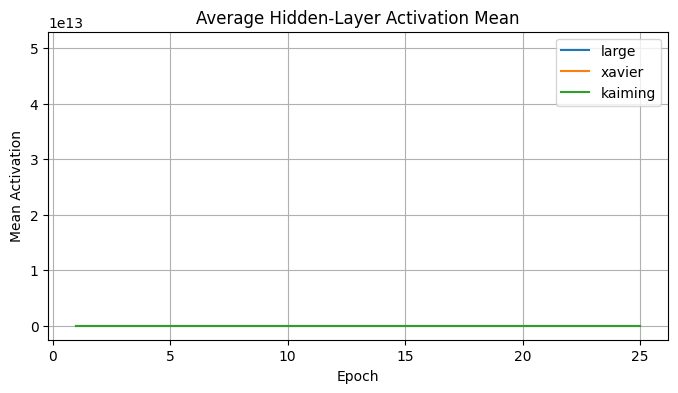

In [31]:
plt.figure(figsize=(8,4))

for initialization in initializations:
    data = np.array(results[initialization]["activation_mean"])

    # Average across the 20 hidden layers for a simple overview.
    mean_over_layers = data.mean(axis=1)

    plt.plot(
        range(1, epochs + 1),
        mean_over_layers,
        label=initialization
    )

plt.xlabel("Epoch")
plt.ylabel("Mean Activation")
plt.title("Average Hidden-Layer Activation Mean")
plt.legend()
plt.grid(True)
plt.show()

## 10. Plot Activation Variance Across Epochs

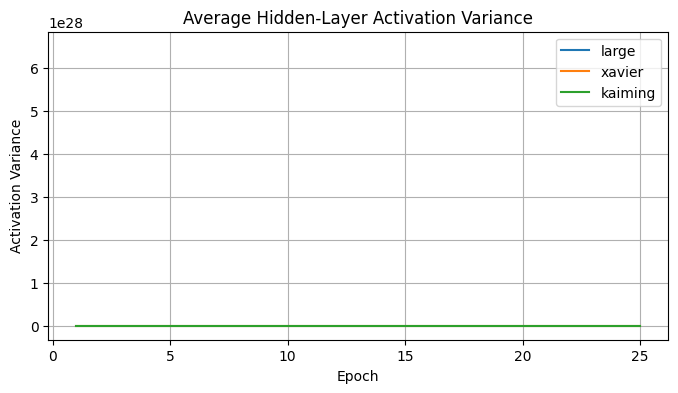

In [32]:
plt.figure(figsize=(8, 4))

for initialization in initializations:
    data = np.array(results[initialization]["activation_variance"])

    mean_over_layers = data.mean(axis=1)

    plt.plot(
        range(1, epochs + 1),
        mean_over_layers,
        label=initialization
    )

plt.xlabel("Epoch")
plt.ylabel("Activation Variance")
plt.title("Average Hidden-Layer Activation Variance")
plt.legend()
plt.grid(True)
plt.show()

## 11. Plot Gradient Magnitude Across Epochs

Very small gradient values can indicate **vanishing gradients**.

Very large gradient values can indicate **exploding gradients**.

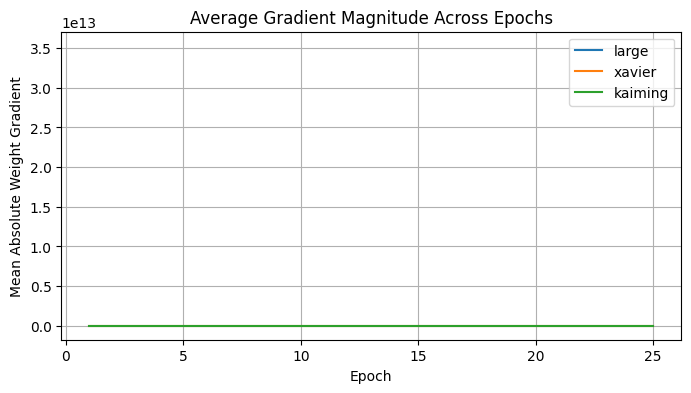

In [33]:
plt.figure(figsize=(8, 4))

for initialization in initializations:
    data = np.array(results[initialization]["gradient_mean"])

    mean_over_layers = data.mean(axis=1)

    plt.plot(
        range(1, epochs + 1),
        mean_over_layers,
        label=initialization
    )

plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Weight Gradient")
plt.title("Average Gradient Magnitude Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

## 12. Gradient Magnitude Across the 20 Layers



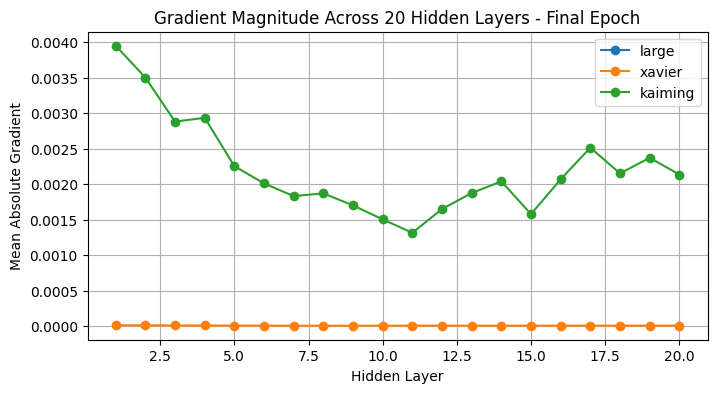

In [34]:
plt.figure(figsize=(8, 4))

for initialization in initializations:
    data = np.array(results[initialization]["gradient_mean"])

    final_gradients = data[-1]

    plt.plot(
        range(1, hidden_layers + 1),
        final_gradients[:-1],  # Exclude the gradient of the output layer
        marker="o",
        label=initialization
    )

plt.xlabel("Hidden Layer")
plt.ylabel("Mean Absolute Gradient")
plt.title("Gradient Magnitude Across 20 Hidden Layers - Final Epoch")
plt.legend()
plt.grid(True)
plt.show()

## 13. Activation Variance Across the 20 Layers

For a healthy initialization, the activation variance should remain reasonably controlled instead of becoming extremely small or extremely large as depth increases.

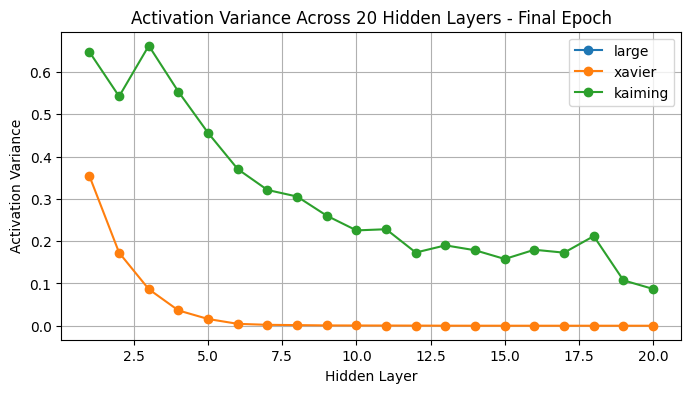

In [35]:
plt.figure(figsize=(8,4))

for initialization in initializations:
    data = np.array(results[initialization]["activation_variance"])

    final_variance = data[-1]

    plt.plot(
        range(1, hidden_layers + 1),
        final_variance,
        marker="o",
        label=initialization
    )

plt.xlabel("Hidden Layer")
plt.ylabel("Activation Variance")
plt.title("Activation Variance Across 20 Hidden Layers - Final Epoch")
plt.legend()
plt.grid(True)
plt.show()

## 14. Heatmap of Gradient Magnitudes



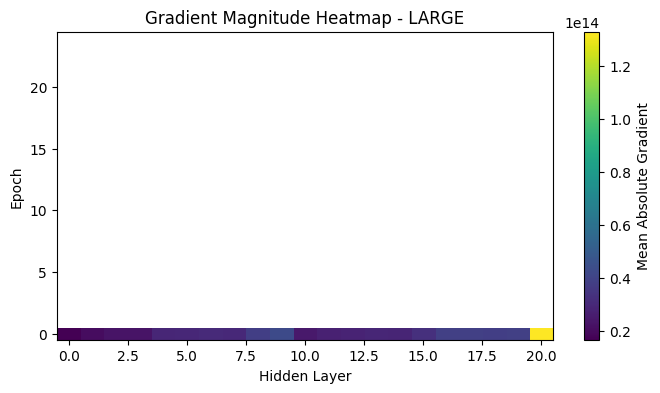

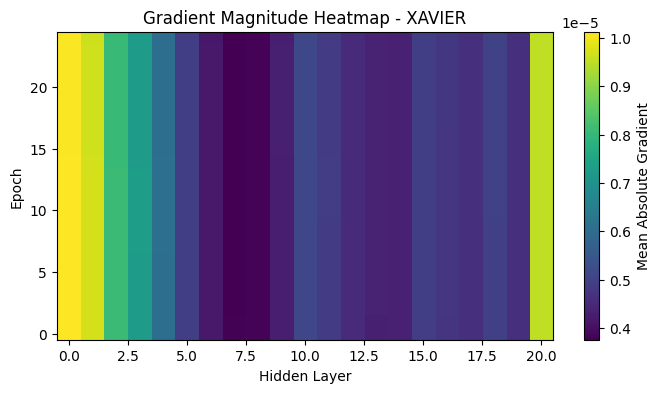

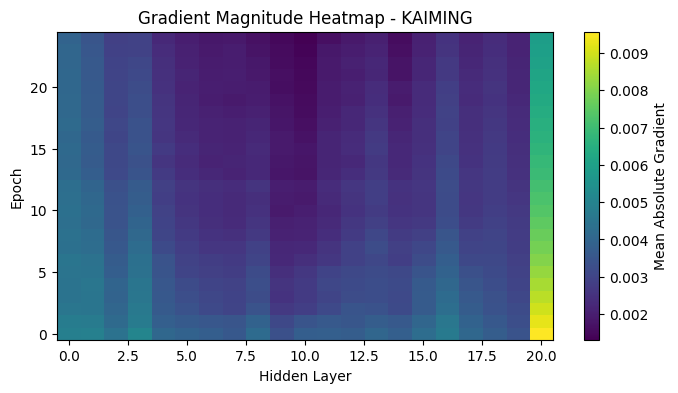

In [36]:
for initialization in initializations:

    data = np.array(
        results[initialization]["gradient_mean"]
    )

    plt.figure(figsize=(8,4))

    plt.imshow(
        data,
        aspect="auto",
        origin="lower"
    )

    plt.colorbar(label="Mean Absolute Gradient")
    plt.xlabel("Hidden Layer")
    plt.ylabel("Epoch")
    plt.title(
        f"Gradient Magnitude Heatmap - {initialization.upper()}"
    )

    plt.show()

## 15. Initial Weight Statistics

This confirms that the three experiments really started with different distributions.

In [37]:
for initialization in initializations:

    weights, biases = build_network(initialization)

    print("\n" + initialization.upper())

    for layer, W in enumerate(weights[:hidden_layers], start=1):
        print(
            f"Layer {layer:2d}: "
            f"mean = {W.mean().item(): .5f}, "
            f"variance = {W.var().item(): .5f}"
        )


LARGE
Layer  1: mean = -0.00150, variance =  0.99701
Layer  2: mean =  0.01089, variance =  0.97236
Layer  3: mean = -0.01939, variance =  0.97316
Layer  4: mean =  0.00678, variance =  1.00044
Layer  5: mean =  0.00314, variance =  1.00902
Layer  6: mean = -0.01112, variance =  0.98082
Layer  7: mean =  0.01324, variance =  0.99586
Layer  8: mean = -0.01180, variance =  0.96824
Layer  9: mean = -0.00054, variance =  0.99714
Layer 10: mean = -0.00278, variance =  1.02768
Layer 11: mean =  0.01591, variance =  1.02030
Layer 12: mean =  0.00920, variance =  1.01702
Layer 13: mean = -0.00276, variance =  1.01540
Layer 14: mean =  0.00084, variance =  0.98114
Layer 15: mean = -0.00618, variance =  1.00844
Layer 16: mean = -0.02933, variance =  1.01697
Layer 17: mean =  0.00671, variance =  1.01386
Layer 18: mean = -0.01403, variance =  1.02131
Layer 19: mean =  0.00025, variance =  1.01906
Layer 20: mean = -0.00388, variance =  0.99159

XAVIER
Layer  1: mean =  0.00030, variance =  0.0153

## 16. Final Diagnostic Summary

The following table-like output gives the average gradient magnitude at the first and last hidden layers.

If the first hidden layer has a much smaller gradient than the deeper layers, this is evidence that the gradient is becoming weaker as it travels backwards.

In [38]:
for initialization in initializations:

    gradient_data = np.array(
        results[initialization]["gradient_mean"]
    )

    first_layer = gradient_data[-1, 0]
    last_layer = gradient_data[-1, -1]

    print(
        f"{initialization.upper():8s} | "
        f"First hidden layer gradient = {first_layer:.8e} | "
        f"Last hidden layer gradient = {last_layer:.8e}"
    )

LARGE    | First hidden layer gradient = nan | Last hidden layer gradient = nan
XAVIER   | First hidden layer gradient = 1.00944044e-05 | Last hidden layer gradient = 9.51097354e-06
KAIMING  | First hidden layer gradient = 3.94993462e-03 | Last hidden layer gradient = 5.89434989e-03
